# How Reliable Are Machine-Learning SBP Estimates Across Blood-Pressure Ranges?

### A clinical error-profile study using NHANES 2017–March 2020 data

**Research question.** How reliable are machine-learning estimates of systolic blood pressure across clinically important blood-pressure ranges?

**Answer.** Reliability changes sharply across the observed SBP distribution. A tuned Random Forest achieved **R² 0.372**, **MAE 11.18 mmHg**, and **RMSE 15.35 mmHg** on held-out data, yet those aggregate scores concealed systematic regression toward the mean. For observed SBP ≥160 mmHg, the model underpredicted every case and missed by **40.75 mmHg on average**.

**Decision.** Do not deploy for clinical use. The project demonstrates rigorous model evaluation by showing why a plausible overall score is not enough when errors concentrate in clinically consequential ranges.

This is the concise portfolio version. The [full technical notebook](01-project-notebook-reframed-reliability.ipynb) contains expanded EDA, regression diagnostics, tuning, range-specific analysis, and SHAP-based failure investigation.

## 1. Reliability study design

- **Data:** NHANES 2017–March 2020 pre-pandemic public-use files
- **Population:** participants aged 8 years or older with measured SBP
- **Target:** mean of up to three oscillometric SBP readings
- **Predictors:** age, BMI, sex, and self-reported diabetes status
- **Validation:** 80/20 train-test split; five-fold cross-validation only within training data
- **Overall metrics:** R², MAE, and RMSE
- **Primary reliability evidence:** direction and magnitude of errors across observed SBP ranges, supported by subgroup and extreme-case analysis

Participants younger than 8 are excluded because NHANES did not collect SBP for that age group by design. BP medication is omitted from the primary model because its availability is structurally restricted to a selected subgroup. The SBP ranges are descriptive bins for error profiling, not diagnostic categories.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import shap
import statsmodels.formula.api as smf

from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 20)
plt.style.use("seaborn-v0_8-whitegrid")

# Works when launched from either the repository root or notebook/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
FIGURE_DIR = PROJECT_ROOT / "Figures"
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## 2. Acquire and construct the analytical cohort

In [2]:
NHANES_FILES = {
    "demo": ("P_DEMO.XPT", "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DEMO.XPT"),
    "bmi": ("P_BMX.XPT", "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_BMX.XPT"),
    "bp": ("P_BPXO.XPT", "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_BPXO.XPT"),
    "diabetes": ("P_DIQ.XPT", "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DIQ.XPT"),
}

for filename, url in NHANES_FILES.values():
    destination = RAW_DATA_DIR / filename
    if not destination.exists():
        response = requests.get(url, timeout=60)
        response.raise_for_status()
        destination.write_bytes(response.content)

demo_df = pd.read_sas(RAW_DATA_DIR / "P_DEMO.XPT")
bmi_df = pd.read_sas(RAW_DATA_DIR / "P_BMX.XPT")
bp_df = pd.read_sas(RAW_DATA_DIR / "P_BPXO.XPT")
diabetes_df = pd.read_sas(RAW_DATA_DIR / "P_DIQ.XPT")

In [3]:
analysis_df = (
    demo_df[["SEQN", "RIDAGEYR", "RIAGENDR"]]
    .merge(bmi_df[["SEQN", "BMXBMI"]], on="SEQN", how="left", validate="one_to_one")
    .merge(bp_df[["SEQN", "BPXOSY1", "BPXOSY2", "BPXOSY3"]], on="SEQN", how="left", validate="one_to_one")
    .merge(diabetes_df[["SEQN", "DIQ010"]], on="SEQN", how="left", validate="one_to_one")
)

analysis_df["Average_SBP"] = analysis_df[["BPXOSY1", "BPXOSY2", "BPXOSY3"]].mean(axis=1)
analysis_df["Sex"] = analysis_df["RIAGENDR"].map({1: "Male", 2: "Female"})
analysis_df["Diabetes"] = analysis_df["DIQ010"].map({1: "Yes", 2: "No", 3: "Borderline"})

eligible_df = analysis_df.loc[analysis_df["RIDAGEYR"] >= 8].copy()
model_df = eligible_df[["Average_SBP", "RIDAGEYR", "BMXBMI", "Sex", "Diabetes"]].dropna().copy()

cohort_flow = pd.DataFrame({
    "Stage": ["Merged NHANES sample", "Age ≥ 8", "Complete modeling cohort"],
    "Participants": [len(analysis_df), len(eligible_df), len(model_df)],
})
cohort_flow

,Stage,Participants
0,Merged NHANES sample,15560
1,Age ≥ 8,12608
2,Complete modeling cohort,10257


The complete-case cohort contains **10,257 participants**. Complete-case analysis keeps the workflow transparent, but it can introduce selection bias if missing BMI or diabetes status is related to SBP; this is a limitation rather than proof that the retained sample is representative.

## 3. Outcome coverage and predictor context

Before judging reliability, the analysis checks the distribution of SBP and the signal available from four routine predictors. Rare high-SBP observations are retained because performance at the extremes is central to the research question.

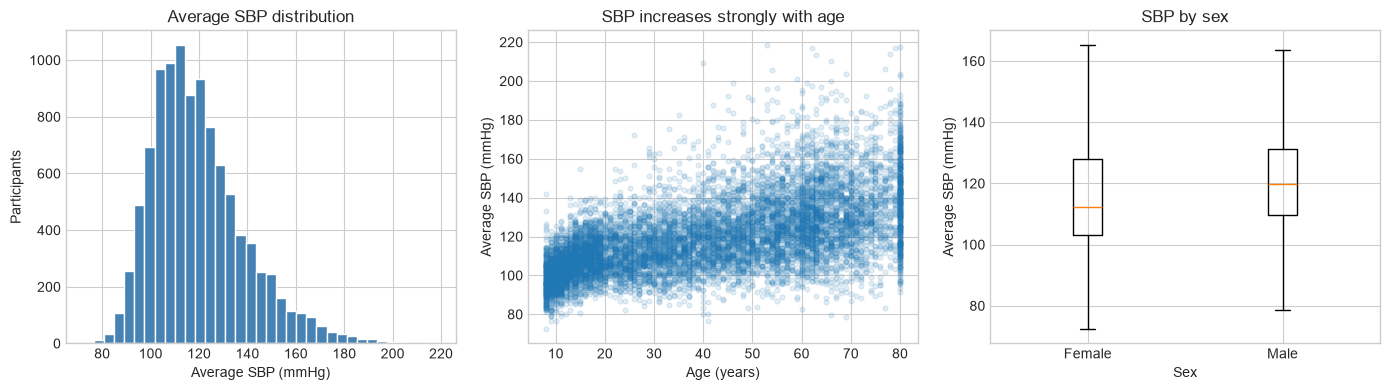

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(model_df["Average_SBP"], bins=35, color="steelblue", edgecolor="white")
axes[0].set(title="Average SBP distribution", xlabel="Average SBP (mmHg)", ylabel="Participants")

axes[1].scatter(model_df["RIDAGEYR"], model_df["Average_SBP"], alpha=0.12, s=12)
axes[1].set(title="SBP increases strongly with age", xlabel="Age (years)", ylabel="Average SBP (mmHg)")

sex_data = [model_df.loc[model_df["Sex"] == group, "Average_SBP"] for group in ["Female", "Male"]]
axes[2].boxplot(sex_data, tick_labels=["Female", "Male"], showfliers=False)
axes[2].set(title="SBP by sex", xlabel="Sex", ylabel="Average SBP (mmHg)")

plt.tight_layout()
plt.show()

In [5]:
eda_summary = pd.DataFrame({
    "Participants": [len(model_df)],
    "Mean SBP": [model_df["Average_SBP"].mean()],
    "SBP SD": [model_df["Average_SBP"].std()],
    "Age–SBP correlation": [model_df[["RIDAGEYR", "Average_SBP"]].corr().iloc[0, 1]],
    "BMI–SBP correlation": [model_df[["BMXBMI", "Average_SBP"]].corr().iloc[0, 1]],
}).round(3)
eda_summary

,Participants,Mean SBP,SBP SD,Age–SBP correlation,BMI–SBP correlation
0,10257,119.719,19.33,0.585,0.215


Age has the clearest unadjusted relationship with SBP. BMI and sex contain additional signal, but none of these descriptive associations should be interpreted causally: NHANES is observational, and this analysis does not control for all relevant confounding factors.

## 4. Interpretable reliability baseline

In [6]:
ols_model = smf.ols(
    'Average_SBP ~ RIDAGEYR + BMXBMI + C(Sex, Treatment(reference="Male")) + C(Diabetes, Treatment(reference="No"))',
    data=model_df,
).fit()

ols_results = pd.DataFrame({
    "Coefficient": ols_model.params,
    "95% CI Lower": ols_model.conf_int()[0],
    "95% CI Upper": ols_model.conf_int()[1],
    "p-value": ols_model.pvalues,
}).round(3)

print(f"OLS R²: {ols_model.rsquared:.3f} | Adjusted R²: {ols_model.rsquared_adj:.3f}")
ols_results

OLS R²: 0.358 | Adjusted R²: 0.357


,Coefficient,95% CI Lower,95% CI Upper,p-value
Intercept,98.384,97.205,99.562,0.000
"C(Sex, Treatment(reference=""Male""))[T.Female]",-4.608,-5.211,-4.006,0.000
"C(Diabetes, Treatment(reference=""No""))[T.Borderline]",0.200,-1.817,2.217,0.846
"C(Diabetes, Treatment(reference=""No""))[T.Yes]",-0.328,-1.335,0.680,0.524
RIDAGEYR,0.492,0.478,0.507,0.000
BMXBMI,0.125,0.084,0.165,0.000


The OLS baseline explains about **35.8%** of the observed variance, establishing that much of the individual variation remains unexplained before nonlinear models are considered. Holding the included predictors constant, age has the largest and most consistent association with SBP. These coefficients quantify conditional associations in this dataset—not treatment effects or biological causation.

## 5. Select a model without leaking test information

In [7]:
X = model_df[["RIDAGEYR", "BMXBMI", "Sex", "Diabetes"]].copy()
y = model_df["Average_SBP"].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

diabetes_order = ["No", "Borderline", "Yes"]
for frame in [X_train_raw, X_test_raw]:
    frame["Diabetes"] = pd.Categorical(frame["Diabetes"], categories=diabetes_order)

X_train = pd.get_dummies(X_train_raw, columns=["Sex", "Diabetes"], drop_first=True, dtype=float)
X_test = pd.get_dummies(X_test_raw, columns=["Sex", "Diabetes"], drop_first=True, dtype=float)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

feature_names = ["Age", "BMI", "Sex (Male)", "Diabetes (Borderline)", "Diabetes (Yes)"]
X_train.columns = feature_names
X_test.columns = feature_names

print(f"Training rows: {len(X_train):,} | Untouched test rows: {len(X_test):,}")

Training rows: 8,205 | Untouched test rows: 2,052


The test set is isolated before model comparison. Hyperparameters were selected using training-only cross-validation in the full technical notebook. Here, the selected configurations are re-evaluated with the same five folds; the test set is opened only after Random Forest is chosen.

In [8]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42, n_jobs=1),
    "XGBoost": XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05,
                            objective="reg:squarederror", random_state=42, n_jobs=1),
}

rows = []
for name, model in models.items():
    scores = cross_validate(
        model, X_train, y_train, cv=cv,
        scoring={"r2": "r2", "mae": "neg_mean_absolute_error", "rmse": "neg_root_mean_squared_error"},
        return_train_score=True,
    )
    rows.append({
        "Model": name,
        "Mean Training R²": scores["train_r2"].mean(),
        "Mean CV R²": scores["test_r2"].mean(),
        "CV R² Std Dev": scores["test_r2"].std(),
        "Mean CV MAE": -scores["test_mae"].mean(),
        "Mean CV RMSE": -scores["test_rmse"].mean(),
    })

model_comparison = pd.DataFrame(rows).sort_values("Mean CV R²", ascending=False).reset_index(drop=True)
model_comparison.round(3)

,Model,Mean Training R²,Mean CV R²,CV R² Std Dev,Mean CV MAE,Mean CV RMSE
0,XGBoost,0.404,0.378,0.008,11.237,15.219
1,Random Forest,0.408,0.378,0.009,11.238,15.219
2,Decision Tree,0.399,0.365,0.010,11.366,15.383
3,Linear Regression,0.361,0.357,0.011,11.525,15.476


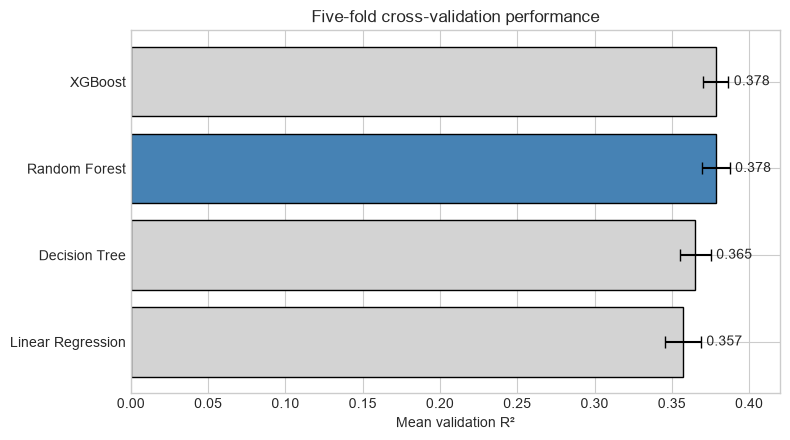

In [9]:
plot_df = model_comparison.sort_values("Mean CV R²")
colors = ["steelblue" if name == "Random Forest" else "lightgray" for name in plot_df["Model"]]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(plot_df["Model"], plot_df["Mean CV R²"],
               xerr=plot_df["CV R² Std Dev"], color=colors, edgecolor="black", capsize=4)
ax.bar_label(bars, labels=[f"{v:.3f}" for v in plot_df["Mean CV R²"]], padding=4)
ax.set(title="Five-fold cross-validation performance", xlabel="Mean validation R²", xlim=(0, 0.42))
plt.tight_layout()
plt.show()

Random Forest and XGBoost are effectively tied; the difference in mean CV R² is negligible relative to fold-to-fold variation. Random Forest is selected because it achieves comparable performance with fewer tuning decisions and a simpler explanation. This is a pragmatic choice, not evidence that Random Forest is universally superior—and the near tie suggests algorithm choice is not the main constraint on reliability.

## 6. Aggregate performance is only the starting point

In [10]:
final_model = RandomForestRegressor(
    n_estimators=50, max_depth=5, random_state=42, n_jobs=1
)
final_model.fit(X_train, y_train)
y_test_pred = final_model.predict(X_test)

test_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Test R²": [r2_score(y_test, y_test_pred)],
    "Test MAE": [mean_absolute_error(y_test, y_test_pred)],
    "Test RMSE": [mean_squared_error(y_test, y_test_pred) ** 0.5],
})
test_results.round(3)

,Model,Test R²,Test MAE,Test RMSE
0,Random Forest,0.372,11.182,15.345


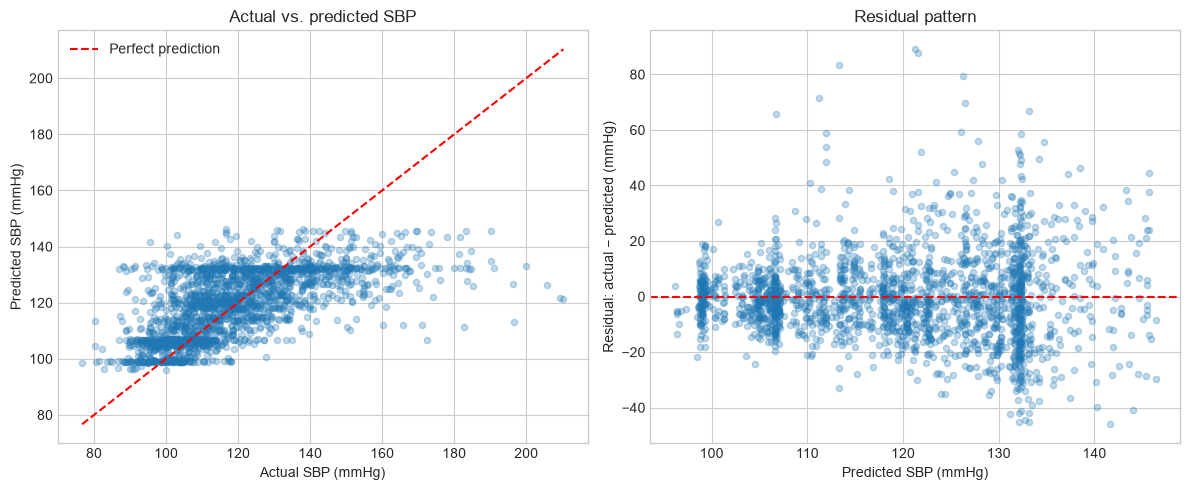

In [11]:
residuals = y_test - y_test_pred
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_test_pred, alpha=0.28, s=20)
limits = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
axes[0].plot(limits, limits, "r--", label="Perfect prediction")
axes[0].set(title="Actual vs. predicted SBP", xlabel="Actual SBP (mmHg)", ylabel="Predicted SBP (mmHg)")
axes[0].legend()

axes[1].scatter(y_test_pred, residuals, alpha=0.28, s=20)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set(title="Residual pattern", xlabel="Predicted SBP (mmHg)", ylabel="Residual: actual − predicted (mmHg)")

plt.tight_layout()
plt.show()

The held-out R² is close to the cross-validation estimate, so there is no evidence of a large generalization collapse. But the scatterplot reveals the more important result: estimates are compressed toward the population mean. A single overall score therefore cannot establish reliability across the clinically important low and high ends of SBP.

## 7. Primary result: reliability by observed SBP range

In [12]:
error_df = pd.DataFrame({
    "Actual SBP": y_test,
    "Predicted SBP": y_test_pred,
    "Age": X_test_raw.loc[y_test.index, "RIDAGEYR"],
    "Sex": X_test_raw.loc[y_test.index, "Sex"],
    "Diabetes": X_test_raw.loc[y_test.index, "Diabetes"].astype(str),
})
error_df["Residual"] = error_df["Actual SBP"] - error_df["Predicted SBP"]
error_df["Absolute Error"] = error_df["Residual"].abs()
error_df["Squared Error"] = error_df["Residual"] ** 2

error_df["Observed SBP Range"] = pd.cut(
    error_df["Actual SBP"], [-np.inf, 100, 120, 140, 160, np.inf],
    labels=["<100", "100–119", "120–139", "140–159", "160+"], right=False,
)

error_by_sbp = error_df.groupby("Observed SBP Range", observed=True).agg(
    Participants=("Actual SBP", "size"),
    Mean_Actual_SBP=("Actual SBP", "mean"),
    Mean_Predicted_SBP=("Predicted SBP", "mean"),
    Mean_Residual=("Residual", "mean"),
    MAE=("Absolute Error", "mean"),
    RMSE=("Squared Error", lambda values: np.sqrt(values.mean())),
).round(2)
error_by_sbp

,Participants,Mean_Actual_SBP,Mean_Predicted_SBP,Mean_Residual,MAE,RMSE
Observed SBP Range,,,,,,
<100,249,94.37,107.62,-13.25,13.27,16.72
100–119,945,109.64,115.99,-6.35,9.09,11.94
120–139,564,128.63,125.42,3.21,7.16,9.02
140–159,213,147.97,130.62,17.35,17.43,19.20
160+,81,172.66,131.91,40.75,40.75,43.67


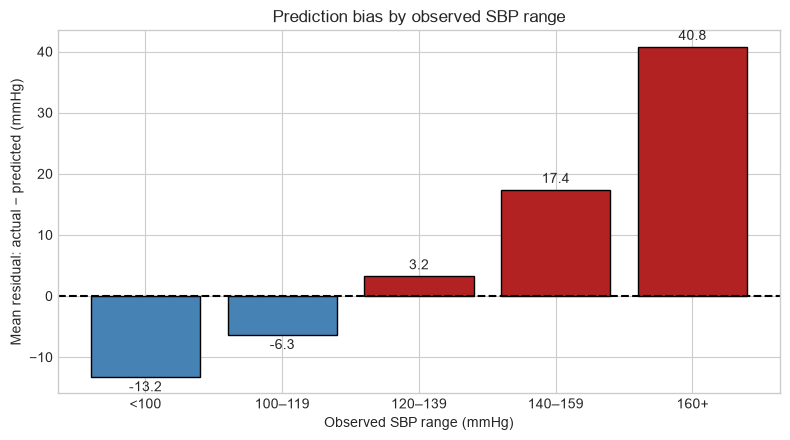

In [13]:
plot_data = error_by_sbp.reset_index()
colors = ["steelblue" if value < 0 else "firebrick" for value in plot_data["Mean_Residual"]]
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(plot_data["Observed SBP Range"].astype(str), plot_data["Mean_Residual"],
              color=colors, edgecolor="black")
ax.axhline(0, color="black", linestyle="--")
ax.bar_label(bars, labels=[f"{v:.1f}" for v in plot_data["Mean_Residual"]], padding=3)
ax.set(title="Prediction bias by observed SBP range", xlabel="Observed SBP range (mmHg)",
       ylabel="Mean residual: actual − predicted (mmHg)")
plt.tight_layout()
plt.show()

In [14]:
def grouped_error(group):
    return error_df.groupby(group, observed=True).agg(
        Participants=("Actual SBP", "size"),
        Mean_Residual=("Residual", "mean"),
        MAE=("Absolute Error", "mean"),
        RMSE=("Squared Error", lambda values: np.sqrt(values.mean())),
    ).round(2)

error_df["Age Group"] = pd.cut(
    error_df["Age"], [8, 18, 40, 60, 80, np.inf],
    labels=["8–17", "18–39", "40–59", "60–79", "80+"], right=False,
)

print("Performance by age")
display(grouped_error("Age Group"))
print("Performance by sex")
display(grouped_error("Sex"))
print("Performance by diabetes status")
display(grouped_error("Diabetes"))

Performance by age


,Participants,Mean_Residual,MAE,RMSE
Age Group,,,,
8–17,439,-0.30,6.38,8.13
18–39,546,0.20,8.53,11.86
40–59,531,-0.51,12.99,17.15
60–79,458,-0.40,16.01,20.39
80+,78,-0.25,16.13,19.89


Performance by sex


,Participants,Mean_Residual,MAE,RMSE
Sex,,,,
Female,1032,-0.11,11.43,15.95
Male,1020,-0.37,10.93,14.71


Performance by diabetes status


,Participants,Mean_Residual,MAE,RMSE
Diabetes,,,,
Borderline,45,0.02,13.07,16.39
No,1776,-0.28,10.70,14.87
Yes,231,0.01,14.56,18.41


Reliability is not uniform. The model performs best in the 120–139 mmHg range (**MAE 7.16 mmHg**), overpredicts lower SBP, and increasingly underpredicts higher SBP. At observed SBP ≥160 mmHg, all 81 estimates are too low and mean underprediction reaches **40.75 mmHg**. MAE also rises with age and among participants with diabetes; these subgroup comparisons are descriptive, not formal fairness tests.

## 8. Why the reliability failures occur

SHAP connects the error profile to the fitted model's behavior by showing how features move an estimate above or below its baseline. Permutation importance separately tests which features held-out performance depends on. These tools explain reliance and failure mechanisms; they do not establish causality or make the estimates clinically valid.

In [15]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_test)

reconstructed_predictions = shap_values.base_values + shap_values.values.sum(axis=1)
assert np.allclose(reconstructed_predictions, y_test_pred, atol=1e-6)

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean Absolute SHAP": np.abs(shap_values.values).mean(axis=0),
}).sort_values("Mean Absolute SHAP", ascending=False)

print(f"SHAP additivity check: passed")
print(f"Mean model baseline: {np.mean(shap_values.base_values):.2f} mmHg")
shap_importance.round(3)

SHAP additivity check: passed
Mean model baseline: 119.79 mmHg


,Feature,Mean Absolute SHAP
0,Age,9.703
2,Sex (Male),2.212
1,BMI,0.890
4,Diabetes (Yes),0.020
3,Diabetes (Borderline),0.003


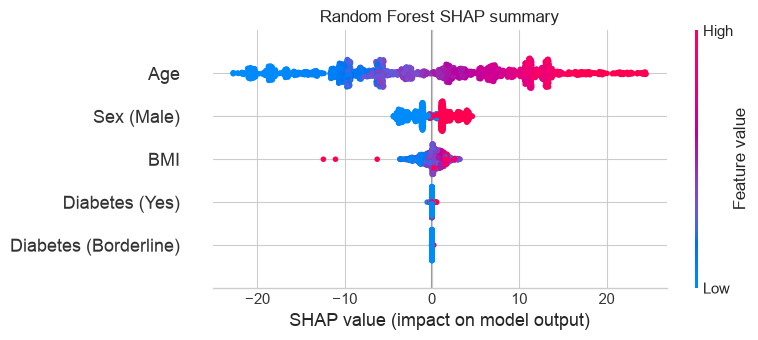

In [16]:
shap.summary_plot(shap_values.values, X_test, feature_names=feature_names, show=False)
plt.title("Random Forest SHAP summary")
plt.tight_layout()
plt.show()

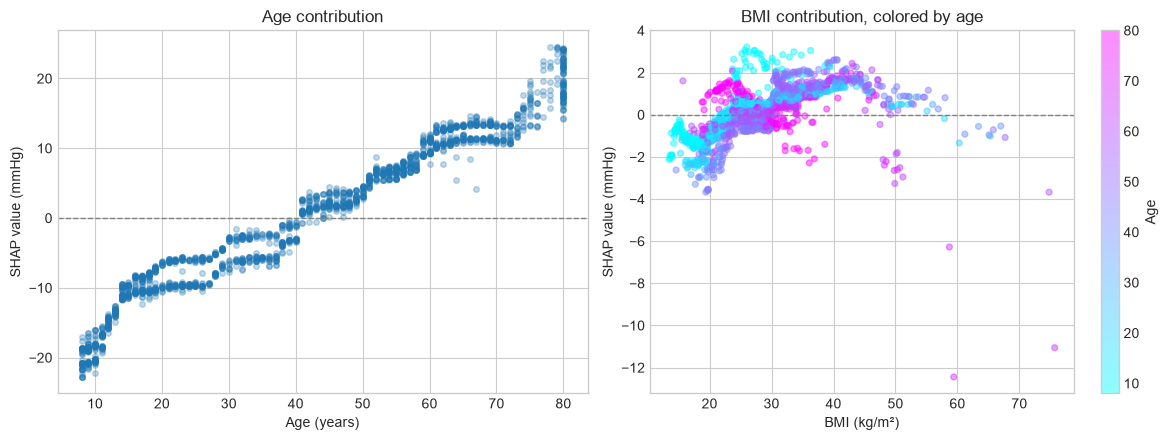

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(X_test["Age"], shap_values.values[:, 0], alpha=0.28, s=16)
axes[0].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[0].set(title="Age contribution", xlabel="Age (years)", ylabel="SHAP value (mmHg)")

scatter = axes[1].scatter(
    X_test["BMI"], shap_values.values[:, 1], c=X_test["Age"],
    cmap="cool", alpha=0.45, s=18,
)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1].set(title="BMI contribution, colored by age", xlabel="BMI (kg/m²)", ylabel="SHAP value (mmHg)")
fig.colorbar(scatter, ax=axes[1], label="Age")

plt.tight_layout()
plt.show()

Age produces a strong nonlinear increase in predicted SBP and crosses the baseline contribution around the early-to-mid 40s. BMI contributions are much smaller and become unstable in sparsely represented extreme-BMI regions, particularly among older participants. With little information beyond age, estimates remain close to demographic averages; sparse extreme-BMI behavior can worsen individual failures. This is learned model behavior—not evidence that very high BMI lowers actual SBP.

,Case,Actual SBP,Predicted SBP,Residual,Age,Sex,Diabetes
5586,Largest underprediction,210.33,121.25,89.08,66.0,Female,No
6177,Largest overprediction,95.67,141.68,-46.01,80.0,Female,No


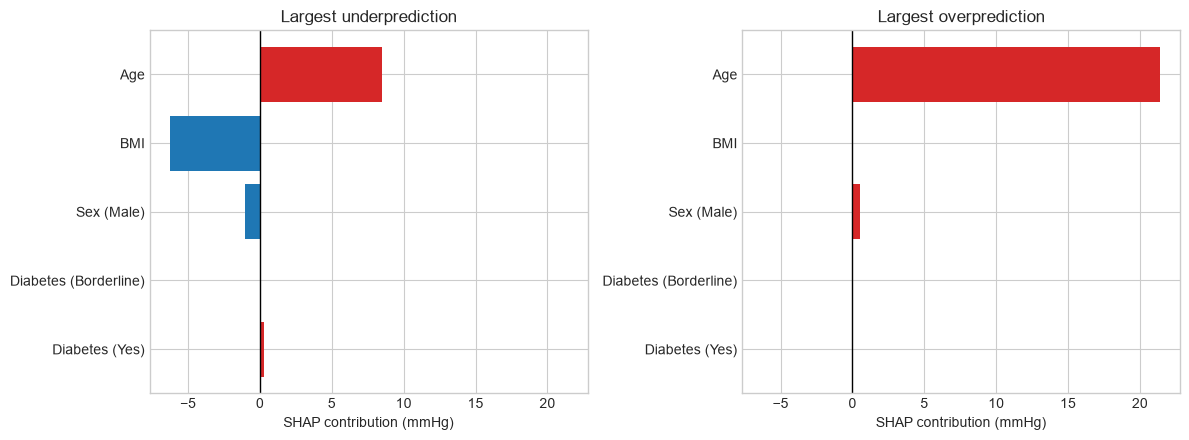

In [18]:
worst_under_index = error_df["Residual"].idxmax()
worst_over_index = error_df["Residual"].idxmin()
case_indices = [worst_under_index, worst_over_index]
case_labels = ["Largest underprediction", "Largest overprediction"]
positions = [X_test.index.get_loc(index) for index in case_indices]

local_cases = error_df.loc[case_indices, [
    "Actual SBP", "Predicted SBP", "Residual", "Age", "Sex", "Diabetes"
]].copy()
local_cases.insert(0, "Case", case_labels)
display(local_cases.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
for ax, position, label in zip(axes, positions, case_labels):
    contributions = shap_values.values[position]
    colors = ["#d62728" if value > 0 else "#1f77b4" for value in contributions]
    ax.barh(feature_names, contributions, color=colors)
    ax.axvline(0, color="black", linewidth=1)
    ax.set(title=label, xlabel="SHAP contribution (mmHg)")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

The largest underprediction was **89.08 mmHg**: observed SBP 210.33 versus predicted SBP 121.25. Age raised the prediction, but extreme BMI lowered it substantially, and the limited feature set could not identify the participant's unusually high SBP. The largest overprediction was **46.01 mmHg**: observed SBP 95.67 versus predicted SBP 141.68. The participant was in NHANES's top-coded age group of 80 or older, and age dominated the prediction. These cases make the model's regression toward demographic averages concrete.

In [19]:
permutation = permutation_importance(
    final_model, X_test, y_test, scoring="r2", n_repeats=30, random_state=42, n_jobs=1
)
permutation_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean R² Decrease": permutation.importances_mean,
    "R² Decrease Std Dev": permutation.importances_std,
}).sort_values("Mean R² Decrease", ascending=False)
permutation_df.round(4)

,Feature,Mean R² Decrease,R² Decrease Std Dev
0,Age,0.6717,0.0231
2,Sex (Male),0.0637,0.0053
1,BMI,0.0122,0.0042
3,Diabetes (Borderline),0.0000,0.0000
4,Diabetes (Yes),-0.0001,0.0002


SHAP and permutation importance agree: age dominates, sex is a distant second, BMI contributes weak nonlinear information, and diabetes adds almost no incremental predictive value once the other features are known. Agreement across methods strengthens the explanation for the reliability profile: age dominates while the other features provide too little information to identify unusual SBP within age groups. It does not turn predictive importance into clinical or causal importance.

## 9. Answer and deployment decision

### Answer to the research question

The estimates are reasonably stable as a population-level technical benchmark near the center of the observed SBP distribution, but **they are not reliable across clinically important ranges for individual use**. Aggregate performance masks systematic overestimation at low SBP and severe underestimation at high SBP. The tested nonlinear models improve only modestly on OLS, so added algorithmic complexity does not resolve the core limitation of the four-feature input set.

### Evidence behind the decision

- Held-out performance is consistent with cross-validation, but only **37.2%** of variance is explained.
- Best range-specific performance occurs at 120–139 mmHg; error rises sharply outside the center.
- At observed SBP ≥160 mmHg, mean underprediction is **40.75 mmHg**.
- The largest individual underprediction is **89.08 mmHg**.
- SHAP and permutation importance show that age dominates; the remaining predictors cannot reliably distinguish unusual SBP among similar-age participants.
- Error magnitude increases with age and is higher among participants with diabetes, though subgroup estimates are descriptive and some samples are small.

### Deployment recommendation

Do **not** use this model for diagnosis, treatment, triage, risk communication, or patient-care decisions. Direct BP measurement remains preferable whenever available. The appropriate current use is a transparent, nonclinical reliability benchmark or a clearly labeled educational demonstration with synthetic inputs.

Future clinical development would require better predictors, target-sensitivity analysis, uncertainty estimates, separate consideration of pediatric and adult populations, a new validation cycle, external and prospective validation, and explicit safety criteria for high-SBP underprediction.

## 10. Reproducibility notes

- Random seeds are fixed at 42.
- The held-out test set is used once for final evaluation, error profiling, and post-selection explanation—not for model selection.
- Hyperparameter searches and expanded diagnostics are retained in the full technical notebook.
- Package versions are recorded in `requirements.txt`.

**Portfolio takeaway:** the strongest result is the evidence-based decision **not** to deploy a model whose aggregate score conceals unsafe errors across clinically important SBP ranges.